<a href="https://colab.research.google.com/github/santhoshvarma0007/project/blob/main/santosh_full_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = "heart_attack_prediction_india.csv"
df = pd.read_csv(file_path)

# Check initial shape
print("Initial shape:", df.shape)

df.head()



Initial shape: (10000, 26)


,Patient_ID,State_Name,Age,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,...,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Heart_Attack_Risk
0,1,Rajasthan,42,Female,0,0,1,1,0,0,...,119,1,0,4,0,0,157,611025,0,0
1,2,Himachal Pradesh,26,Male,0,0,0,0,1,1,...,115,0,0,7,0,0,331,174527,0,0
2,3,Assam,78,Male,0,0,1,0,0,1,...,117,0,1,10,1,0,186,1760112,1,0
3,4,Odisha,58,Male,1,0,1,0,0,1,...,65,0,0,1,1,1,324,1398213,0,0
4,5,Karnataka,22,Male,0,0,0,0,0,1,...,109,0,0,9,0,0,209,97987,0,1


In [9]:
# View column names, data types, and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Patient_ID               10000 non-null  int64 
 1   State_Name               10000 non-null  object
 2   Age                      10000 non-null  int64 
 3   Gender                   10000 non-null  object
 4   Diabetes                 10000 non-null  int64 
 5   Hypertension             10000 non-null  int64 
 6   Obesity                  10000 non-null  int64 
 7   Smoking                  10000 non-null  int64 
 8   Alcohol_Consumption      10000 non-null  int64 
 9   Physical_Activity        10000 non-null  int64 
 10  Diet_Score               10000 non-null  int64 
 11  Cholesterol_Level        10000 non-null  int64 
 12  Triglyceride_Level       10000 non-null  int64 
 13  LDL_Level                10000 non-null  int64 
 14  HDL_Level                10000 non-null

In [10]:
# Check missing values per column
print("Missing values per column:")
print(df.isna().sum())

# Remove rows with missing values (if any)
rows_before = df.shape[0]
df = df.dropna()
rows_after = df.shape[0]

print("Rows before removal:", rows_before)
print("Rows after removal:", rows_after)


Missing values per column:
Patient_ID                 0
State_Name                 0
Age                        0
Gender                     0
Diabetes                   0
Hypertension               0
Obesity                    0
Smoking                    0
Alcohol_Consumption        0
Physical_Activity          0
Diet_Score                 0
Cholesterol_Level          0
Triglyceride_Level         0
LDL_Level                  0
HDL_Level                  0
Systolic_BP                0
Diastolic_BP               0
Air_Pollution_Exposure     0
Family_History             0
Stress_Level               0
Healthcare_Access          0
Heart_Attack_History       0
Emergency_Response_Time    0
Annual_Income              0
Health_Insurance           0
Heart_Attack_Risk          0
dtype: int64
Rows before removal: 10000
Rows after removal: 10000


In [11]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (10000, 26)


In [12]:
# Patient_ID is an identifier and not a predictive feature
if "Patient_ID" in df.columns:
    df = df.drop(columns=["Patient_ID"])

print("Remaining columns:")
print(df.columns)


Remaining columns:
Index(['State_Name', 'Age', 'Gender', 'Diabetes', 'Hypertension', 'Obesity',
       'Smoking', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Score',
       'Cholesterol_Level', 'Triglyceride_Level', 'LDL_Level', 'HDL_Level',
       'Systolic_BP', 'Diastolic_BP', 'Air_Pollution_Exposure',
       'Family_History', 'Stress_Level', 'Healthcare_Access',
       'Heart_Attack_History', 'Emergency_Response_Time', 'Annual_Income',
       'Health_Insurance', 'Heart_Attack_Risk'],
      dtype='object')


In [13]:
# Examine target distribution
print("Heart_Attack_Risk distribution:")
print(df["Heart_Attack_Risk"].value_counts())

print("\nProportion:")
print(df["Heart_Attack_Risk"].value_counts(normalize=True))


Heart_Attack_Risk distribution:
Heart_Attack_Risk
0    6993
1    3007
Name: count, dtype: int64

Proportion:
Heart_Attack_Risk
0    0.6993
1    0.3007
Name: proportion, dtype: float64


In [14]:
# Basic dataset overview
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Summary statistics (numeric columns)
print("\nSummary statistics (numeric):")
display(df.describe())

# Summary for categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if len(categorical_cols) > 0:
    print("\nSummary statistics (categorical):")
    display(df[categorical_cols].describe())


Dataset shape: (10000, 25)

Columns:
['State_Name', 'Age', 'Gender', 'Diabetes', 'Hypertension', 'Obesity', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Score', 'Cholesterol_Level', 'Triglyceride_Level', 'LDL_Level', 'HDL_Level', 'Systolic_BP', 'Diastolic_BP', 'Air_Pollution_Exposure', 'Family_History', 'Stress_Level', 'Healthcare_Access', 'Heart_Attack_History', 'Emergency_Response_Time', 'Annual_Income', 'Health_Insurance', 'Heart_Attack_Risk']

Summary statistics (numeric):


,Age,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,Diet_Score,Cholesterol_Level,Triglyceride_Level,...,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Heart_Attack_Risk
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,49.394900,0.092900,0.24690,0.303700,0.301400,0.352800,0.595800,5.021700,224.753000,174.733300,...,89.312000,0.403600,0.311300,5.518800,0.311000,0.152500,206.383400,1.022062e+06,0.344700,0.300700
std,17.280301,0.290307,0.43123,0.459878,0.458889,0.477865,0.490761,3.156394,43.359172,71.163447,...,17.396486,0.490644,0.463048,2.866264,0.462926,0.359523,112.391711,5.605978e+05,0.475294,0.458585
min,20.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,50.000000,...,60.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,5.035300e+04,0.000000,0.000000
25%,35.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.000000,187.000000,114.000000,...,74.000000,0.000000,0.000000,3.000000,0.000000,0.000000,110.000000,5.357838e+05,0.000000,0.000000
50%,49.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,5.000000,226.000000,174.000000,...,89.000000,0.000000,0.000000,6.000000,0.000000,0.000000,206.000000,1.021383e+06,0.000000,0.000000
75%,64.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,8.000000,262.000000,236.000000,...,104.000000,1.000000,1.000000,8.000000,1.000000,0.000000,304.000000,1.501670e+06,1.000000,1.000000
max,79.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.000000,299.000000,299.000000,...,119.000000,1.000000,1.000000,10.000000,1.000000,1.000000,399.000000,1.999714e+06,1.000000,1.000000



Summary statistics (categorical):


,State_Name,Gender
count,10000,10000
unique,28,2
top,Chhattisgarh,Male
freq,399,5516


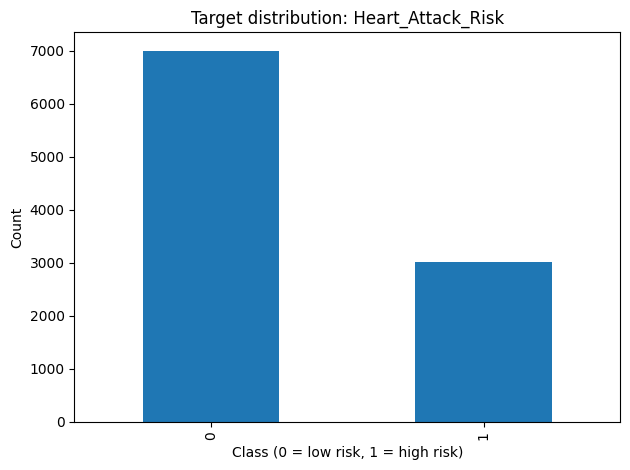

Target proportions:
Heart_Attack_Risk
0    0.6993
1    0.3007
Name: proportion, dtype: float64


In [15]:
import matplotlib.pyplot as plt

# Plot target class counts
counts = df[target_col].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")
plt.title("Target distribution: Heart_Attack_Risk")
plt.xlabel("Class (0 = low risk, 1 = high risk)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Print proportions
print("Target proportions:")
print(df[target_col].value_counts(normalize=True).sort_index())

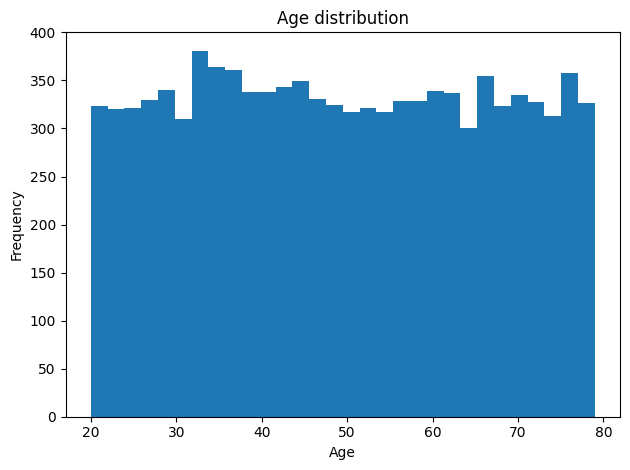

/tmp/ipykernel_3292/3014465115.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_age_group = df.groupby("Age_Group")["Heart_Attack_Risk"].mean()


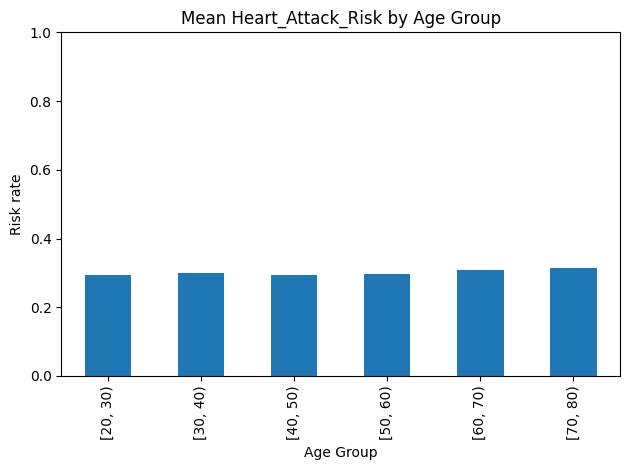

In [16]:
# Age distribution
plt.figure()
df["Age"].plot(kind="hist", bins=30)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Risk rate by age group (bins)
age_bins = [20, 30, 40, 50, 60, 70, 80]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, right=False)

risk_by_age_group = df.groupby("Age_Group")["Heart_Attack_Risk"].mean()

plt.figure()
risk_by_age_group.plot(kind="bar")
plt.title("Mean Heart_Attack_Risk by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Risk rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Drop helper column if you do not want it later
df = df.drop(columns=["Age_Group"])


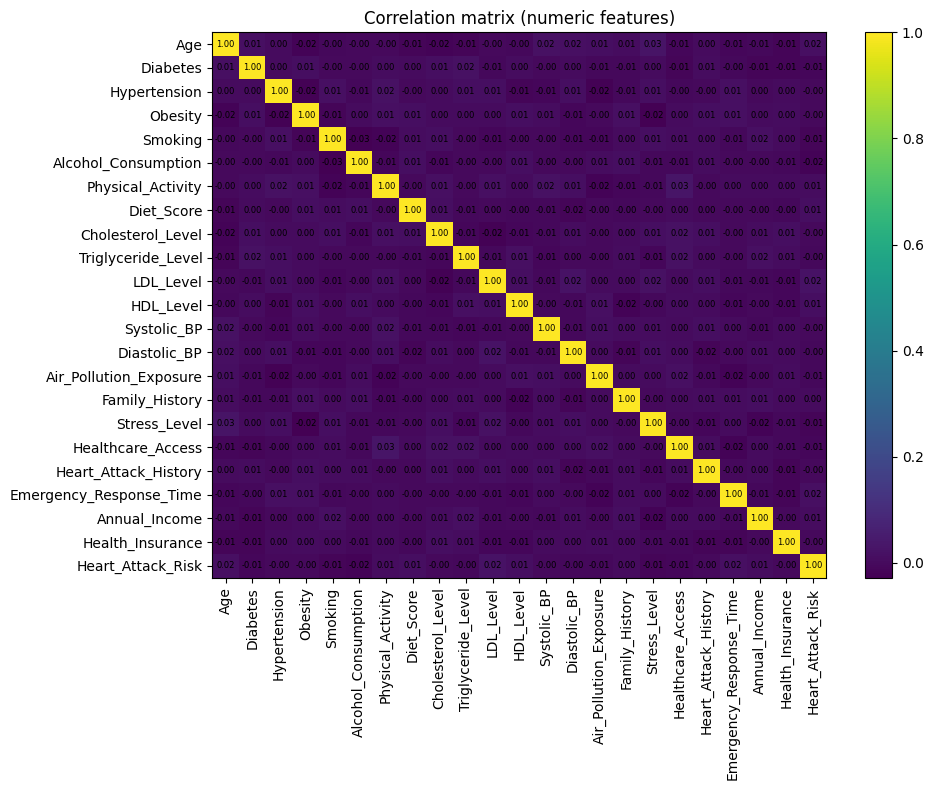

Top correlations with Heart_Attack_Risk (numeric only):


,Heart_Attack_Risk
LDL_Level,0.021228
Alcohol_Consumption,-0.017283
Age,0.015517
Emergency_Response_Time,0.015149
Smoking,-0.012504
Stress_Level,-0.012176
HDL_Level,0.011884
Healthcare_Access,-0.011861
Diet_Score,0.010623
Diabetes,-0.009278


In [17]:
# Correlation analysis for numeric columns
numeric_df = df.select_dtypes(exclude=["object"])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot correlation heatmap with annotations
plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im)

# Add axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values as annotations
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6
        )

plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

# Correlation of numeric features with target
target_corr = (
    corr["Heart_Attack_Risk"]
    .drop("Heart_Attack_Risk")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top correlations with Heart_Attack_Risk (numeric only):")
display(target_corr.head(15))


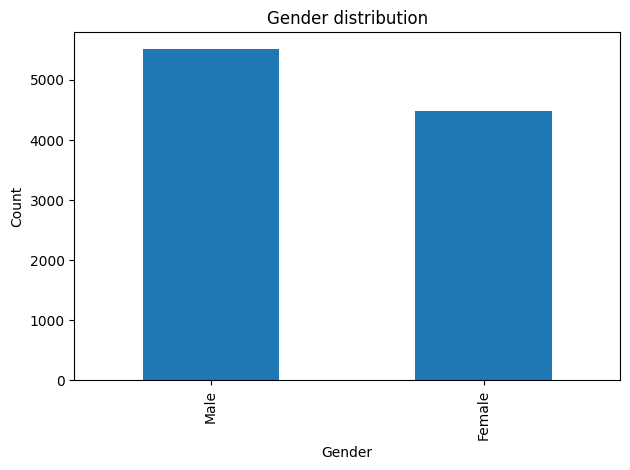

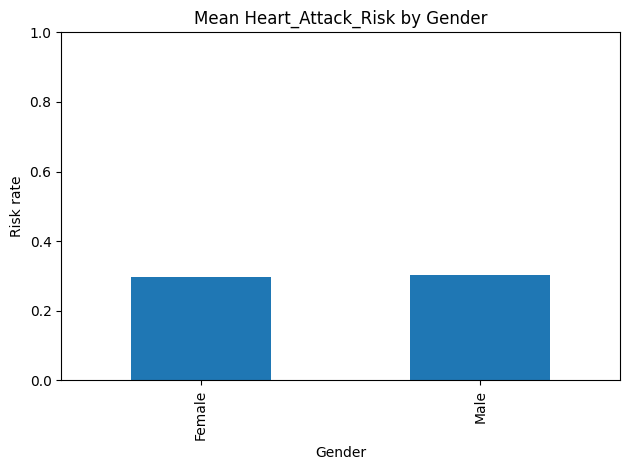

In [18]:
# Gender counts
plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Risk rate by gender
risk_by_gender = df.groupby("Gender")["Heart_Attack_Risk"].mean()

plt.figure()
risk_by_gender.plot(kind="bar")
plt.title("Mean Heart_Attack_Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Risk rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


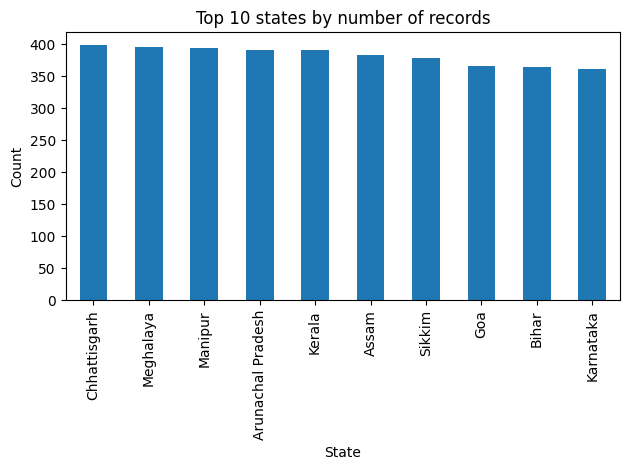

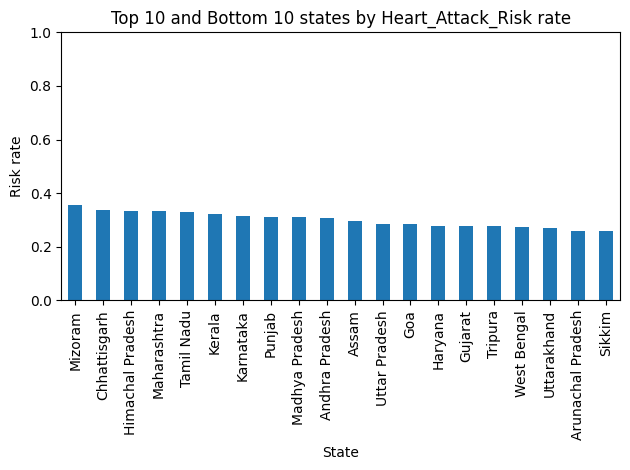

In [19]:
# State counts (top 10)
state_counts = df["State_Name"].value_counts().head(10)

plt.figure()
state_counts.plot(kind="bar")
plt.title("Top 10 states by number of records")
plt.xlabel("State")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# State-wise risk rate (top 10 and bottom 10)
state_risk = df.groupby("State_Name")["Heart_Attack_Risk"].mean().sort_values(ascending=False)
top10 = state_risk.head(10)
bottom10 = state_risk.tail(10)

plt.figure()
pd.concat([top10, bottom10]).plot(kind="bar")
plt.title("Top 10 and Bottom 10 states by Heart_Attack_Risk rate")
plt.xlabel("State")
plt.ylabel("Risk rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [20]:
# Define target variable
target_column = "Heart_Attack_Risk"

# Separate features (X) and target (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10000, 24)
y shape: (10000,)


In [21]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# Stratification is used to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Print shapes after split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7500, 24)
X_test shape: (2500, 24)
y_train shape: (7500,)
y_test shape: (2500,)


In [22]:
# Identify categorical columns
categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()

# Identify numerical columns
numerical_columns = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)


Categorical columns: ['State_Name', 'Gender']
Numerical columns: ['Age', 'Diabetes', 'Hypertension', 'Obesity', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Score', 'Cholesterol_Level', 'Triglyceride_Level', 'LDL_Level', 'HDL_Level', 'Systolic_BP', 'Diastolic_BP', 'Air_Pollution_Exposure', 'Family_History', 'Stress_Level', 'Healthcare_Access', 'Heart_Attack_History', 'Emergency_Response_Time', 'Annual_Income', 'Health_Insurance']


In [23]:
from sklearn.preprocessing import LabelEncoder

# Create copies to avoid modifying original data
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Apply label encoding to each categorical column
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()

    # Fit encoder on training data
    X_train_encoded[col] = le.fit_transform(X_train[col])

    # Transform test data using the same encoder
    X_test_encoded[col] = le.transform(X_test[col])

    # Store encoder for future use
    label_encoders[col] = le

print("Label encoding completed")


Label encoding completed


In [24]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training numerical data
X_train_encoded[numerical_columns] = scaler.fit_transform(
    X_train_encoded[numerical_columns]
)

# Transform test numerical data using the same scaler
X_test_encoded[numerical_columns] = scaler.transform(
    X_test_encoded[numerical_columns]
)

print("Standard scaling completed")


Standard scaling completed


In [25]:
# Final shapes after encoding and scaling
print("Final X_train shape:", X_train_encoded.shape)
print("Final X_test shape:", X_test_encoded.shape)

# Preview processed training data
X_train_encoded.head()


Final X_train shape: (7500, 24)
Final X_test shape: (2500, 24)


,State_Name,Age,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,Diet_Score,...,Systolic_BP,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance
9598,5,-0.483773,1,-0.320086,-0.571808,-0.663811,-0.658397,-0.735090,0.826056,-0.015107,...,0.746557,-1.115736,1.212247,1.478535,-1.224484,-0.670698,-0.423593,1.247213,-0.994076,-0.725860
8332,20,1.134016,1,-0.320086,1.748840,-0.663811,-0.658397,1.360378,0.826056,1.571734,...,0.203290,-1.345701,-0.824915,1.478535,-1.572718,-0.670698,-0.423593,-0.454310,1.475177,1.377676
5217,27,-1.697115,1,-0.320086,1.748840,-0.663811,1.518841,-0.735090,0.826056,-0.649843,...,0.785362,-0.368350,-0.824915,-0.676345,0.864921,1.490984,-0.423593,-1.269623,-1.316899,-0.725860
9066,12,1.711798,1,3.124164,-0.571808,-0.663811,-0.658397,-0.735090,0.826056,-0.649843,...,1.483847,1.126422,1.212247,-0.676345,-0.876250,-0.670698,-0.423593,-0.906277,-1.478112,1.377676
4756,14,0.382900,0,-0.320086,-0.571808,-0.663811,1.518841,-0.735090,0.826056,-0.332475,...,1.600262,-1.633158,-0.824915,-0.676345,-0.179782,-0.670698,-0.423593,1.105419,-0.724862,1.377676


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on training data
dt_model.fit(X_train_encoded, y_train)

# Predict class labels on test data
dt_pred = dt_model.predict(X_test_encoded)

# Print evaluation results
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, digits=4))


Decision Tree Results
Accuracy: 0.5744

Confusion Matrix:
[[1191  557]
 [ 507  245]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7014    0.6814    0.6912      1748
           1     0.3055    0.3258    0.3153       752

    accuracy                         0.5744      2500
   macro avg     0.5034    0.5036    0.5033      2500
weighted avg     0.5823    0.5744    0.5782      2500



In [27]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

svm_balanced = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=42)
svm_balanced.fit(X_train_encoded, y_train)
svm_pred_bal = svm_balanced.predict(X_test_encoded)


print("Balanced SVM predicted class counts:")
print(pd.Series(svm_pred_bal).value_counts().sort_index())

print("\nBalanced SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_pred_bal))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred_bal))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred_bal, digits=4, zero_division=0))


Balanced SVM predicted class counts:
0    1186
1    1314
Name: count, dtype: int64

Balanced SVM Results
Accuracy: 0.4968

Confusion Matrix:
[[838 910]
 [348 404]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7066    0.4794    0.5712      1748
           1     0.3075    0.5372    0.3911       752

    accuracy                         0.4968      2500
   macro avg     0.5070    0.5083    0.4812      2500
weighted avg     0.5865    0.4968    0.5170      2500



In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Initialize XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",
    class_weight="balanced"
)

# Train the model on training data
xgb_model.fit(X_train_encoded, y_train)

# Predict class labels on test data
xgb_pred = xgb_model.predict(X_test_encoded)

# Print evaluation results
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, digits=4))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:53:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
Accuracy: 0.6932

Confusion Matrix:
[[1710   38]
 [ 729   23]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7011    0.9783    0.8168      1748
           1     0.3770    0.0306    0.0566       752

    accuracy                         0.6932      2500
   macro avg     0.5391    0.5044    0.4367      2500
weighted avg     0.6036    0.6932    0.5881      2500



In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    """
    Plots a confusion matrix as a heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
    plt.yticks([0, 1], ["Actual 0", "Actual 1"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


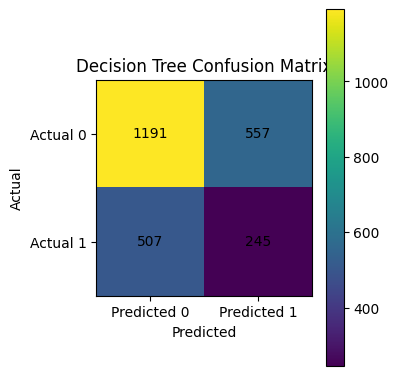

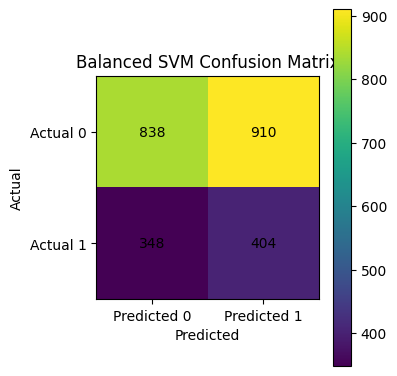

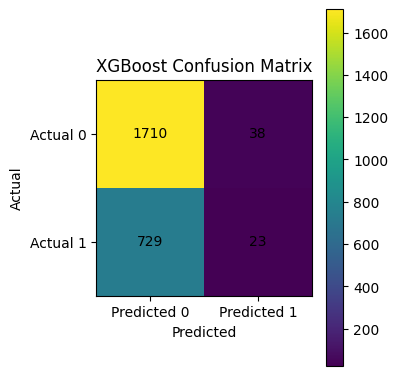

In [30]:
# Decision Tree
plot_confusion_matrix(y_test, dt_pred, "Decision Tree Confusion Matrix")

# Balanced SVM
plot_confusion_matrix(y_test, svm_pred_bal, "Balanced SVM Confusion Matrix")

# XGBoost
plot_confusion_matrix(y_test, xgb_pred, "XGBoost Confusion Matrix")


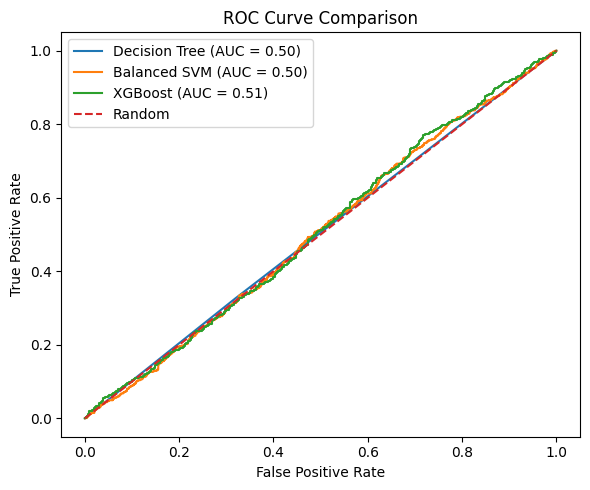

In [31]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6, 5))

# Decision Tree probabilities
dt_prob = dt_model.predict_proba(X_test_encoded)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.2f})")

# Balanced SVM probabilities
svm_prob = svm_balanced.decision_function(X_test_encoded)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
plt.plot(fpr_svm, tpr_svm, label=f"Balanced SVM (AUC = {auc(fpr_svm, tpr_svm):.2f})")

# XGBoost probabilities
xgb_prob = xgb_model.predict_proba(X_test_encoded)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})")

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute probabilities where required
dt_prob = dt_model.predict_proba(X_test_encoded)[:, 1]
svm_prob = svm_balanced.decision_function(X_test_encoded)
xgb_prob = xgb_model.predict_proba(X_test_encoded)[:, 1]

# Create a comparison table
results = pd.DataFrame({
    "Model": ["Decision Tree", "Balanced SVM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, svm_pred_bal),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision (Class 1)": [
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, svm_pred_bal, zero_division=0),
        precision_score(y_test, xgb_pred, zero_division=0)
    ],
    "Recall (Class 1)": [
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, svm_pred_bal, zero_division=0),
        recall_score(y_test, xgb_pred, zero_division=0)
    ],
    "F1-score (Class 1)": [
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, svm_pred_bal, zero_division=0),
        f1_score(y_test, xgb_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results


,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1-score (Class 1),ROC-AUC
0,Decision Tree,0.5744,0.305486,0.325798,0.315315,0.503574
1,Balanced SVM,0.4968,0.307458,0.537234,0.391094,0.504949
2,XGBoost,0.6932,0.377049,0.030585,0.056581,0.509178


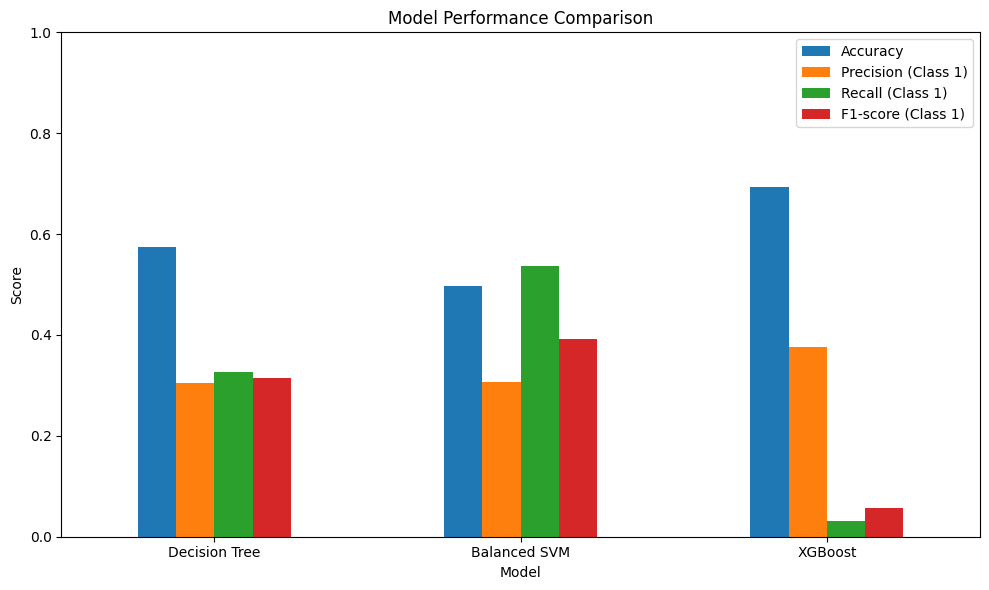

In [33]:
import matplotlib.pyplot as plt

# Set model names as index
results_plot = results.set_index("Model")

# Plot comparison
results_plot[["Accuracy", "Precision (Class 1)", "Recall (Class 1)", "F1-score (Class 1)"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Parameter grid for Decision Tree
dt_param_grid = {
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# Model
dt_model = DecisionTreeClassifier(random_state=42)

# Grid search
dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train_encoded, y_train)

print("Best Decision Tree parameters:")
print(dt_grid.best_params_)

print("\nBest CV score (F1):", dt_grid.best_score_)


Best Decision Tree parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best CV score (F1): 0.31133287048287484


In [35]:
dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test_encoded)

print("Decision Tree (Tuned) Test Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, digits=4, zero_division=0))


Decision Tree (Tuned) Test Accuracy: 0.5836

Confusion Matrix:
[[1244  504]
 [ 537  215]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6985    0.7117    0.7050      1748
           1     0.2990    0.2859    0.2923       752

    accuracy                         0.5836      2500
   macro avg     0.4988    0.4988    0.4987      2500
weighted avg     0.5783    0.5836    0.5809      2500



In [36]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# RBF SVM with class balancing
svm_model = SVC(kernel="rbf", class_weight="balanced", random_state=42)

# Smaller search space
param_dist = {
    "C": np.logspace(-2, 2, 10),          # 0.01 to 100
    "gamma": np.logspace(-3, 0, 10)       # 0.001 to 1
}

# Randomized search reduces the number of model fits
svm_random = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,                 # 3-fold to reduce runtime
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svm_random.fit(X_train_encoded, y_train)

print("Best SVM parameters:")
print(svm_random.best_params_)
print("Best CV F1 score:", svm_random.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best SVM parameters:
{'gamma': np.float64(0.001), 'C': np.float64(0.21544346900318834)}
Best CV F1 score: 0.4308512464394309


In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Get the best SVM estimator
svm_best = svm_random.best_estimator_

# Get decision scores
svm_scores = svm_best.decision_function(X_test_encoded)

# Try different thresholds
thresholds = [0.0, 0.3, 0.5, 0.7]

for t in thresholds:
    preds = (svm_scores >= t).astype(int)

    print(f"\nThreshold = {t}")
    print("Predicted class counts:")
    print(pd.Series(preds).value_counts().sort_index())

    print("Accuracy:", accuracy_score(y_test, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("Classification Report:")
    print(classification_report(y_test, preds, digits=4, zero_division=0))


Threshold = 0.0
Predicted class counts:
0     619
1    1881
Name: count, dtype: int64
Accuracy: 0.4028
Confusion Matrix:
[[ 437 1311]
 [ 182  570]]
Classification Report:
              precision    recall  f1-score   support

           0     0.7060    0.2500    0.3692      1748
           1     0.3030    0.7580    0.4330       752

    accuracy                         0.4028      2500
   macro avg     0.5045    0.5040    0.4011      2500
weighted avg     0.5848    0.4028    0.3884      2500


Threshold = 0.3
Predicted class counts:
0    1055
1    1445
Name: count, dtype: int64
Accuracy: 0.482
Confusion Matrix:
[[754 994]
 [301 451]]
Classification Report:
              precision    recall  f1-score   support

           0     0.7147    0.4314    0.5380      1748
           1     0.3121    0.5997    0.4106       752

    accuracy                         0.4820      2500
   macro avg     0.5134    0.5155    0.4743      2500
weighted avg     0.5936    0.4820    0.4997      2500


Thresh

In [38]:
from xgboost import XGBClassifier

# Parameter grid for XGBoost
xgb_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Grid search
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train_encoded, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest CV score (F1):", xgb_grid.best_score_)


Best XGBoost parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}

Best CV score (F1): 0.15150600572106962


In [39]:
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test_encoded)

print("XGBoost (Tuned) Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, digits=4, zero_division=0))


XGBoost (Tuned) Test Accuracy: 0.6636

Confusion Matrix:
[[1595  153]
 [ 688   64]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6986    0.9125    0.7914      1748
           1     0.2949    0.0851    0.1321       752

    accuracy                         0.6636      2500
   macro avg     0.4968    0.4988    0.4617      2500
weighted avg     0.5772    0.6636    0.5931      2500

